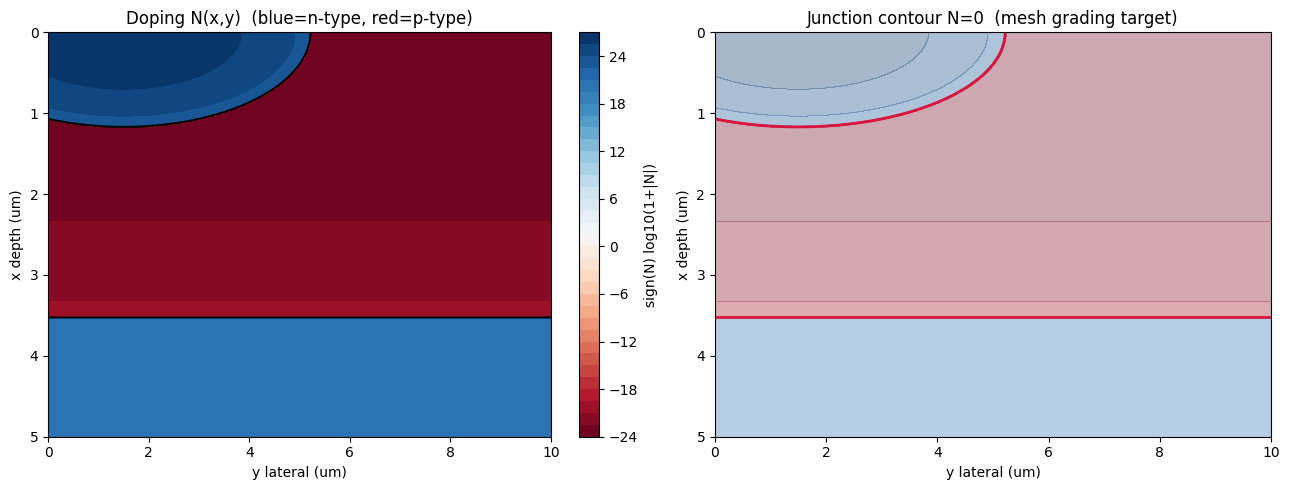

junction contour: 1066 sample points, arc length ~18063899.10 um


In [34]:
import numpy as np
from scipy.spatial import Delaunay, cKDTree
import matplotlib.pyplot as plt

Lx, Ly = 5e-6, 10e-6   # device size (m) -- x = depth, y = lateral

def doping_profile(x, y):
    C_E, sigma_Ex, sigma_Ey, y_E = 5e26, 0.3e-6, 1.0e-6, 1.5e-6
    N_D_emitter = C_E * np.exp(-x**2/(2*sigma_Ex**2)) * np.exp(-(y-y_E)**2/(2*sigma_Ey**2))
    C_B, sigma_Bx = 5e23, 1.0e-6
    N_A_base = C_B * np.exp(-x**2/(2*sigma_Bx**2))
    C_C = 1e21
    N_D_collector = C_C * np.ones_like(np.asarray(x))
    return (N_D_emitter + N_D_collector) - N_A_base

# fine grid for doping / junction visualization
nfine = 600
xg, yg = np.linspace(0, Lx, nfine), np.linspace(0, Ly, nfine)
Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
Ng = doping_profile(Xg, Yg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
signed_log = np.sign(Ng) * np.log10(1.0 + np.abs(Ng))
im = axes[0].contourf(Yg*1e6, Xg*1e6, signed_log, levels=40, cmap="RdBu")
axes[0].contour(Yg*1e6, Xg*1e6, Ng, levels=[0], colors="k", linewidths=1.5)
axes[0].invert_yaxis()
axes[0].set_title("Doping N(x,y)  (blue=n-type, red=p-type)")
axes[0].set_xlabel("y lateral (um)")
axes[0].set_ylabel("x depth (um)")
plt.colorbar(im, ax=axes[0], fraction=0.046, label="sign(N) log10(1+|N|)")

cs = axes[1].contour(Yg*1e6, Xg*1e6, Ng, levels=[0.0], colors="crimson", linewidths=2)
axes[1].contourf(Yg*1e6, Xg*1e6, signed_log, levels=40, cmap="RdBu", alpha=0.35)
axes[1].invert_yaxis()
axes[1].set_title("Junction contour N=0  (mesh grading target)")
axes[1].set_xlabel("y lateral (um)")
axes[1].set_ylabel("x depth (um)")
plt.tight_layout()
plt.show()

junction_pts = np.vstack(cs.allsegs[0])
junction_tree = cKDTree(junction_pts)
print(f"junction contour: {len(junction_pts)} sample points, "
      f"arc length ~{np.sum(np.linalg.norm(np.diff(junction_pts, axis=0), axis=1))*1e6:.2f} um")


In [35]:
def domain_sdf(p):
    """Negative inside the rectangle [0,Lx]x[0,Ly], 0 on boundary, positive outside."""
    x, y = p[:, 0], p[:, 1]
    return -np.minimum(np.minimum(x, Lx - x), np.minimum(y, Ly - y))
    
# concrete numbers, fixed for now -- tune later if needed
h_min       = 15e-9    # ~2.6x the local Debye length at N_ref=5e23 (5.78 nm) -- junction resolution
h_max       = 300e-9   # far-field resolution, away from any junction
grade_length = 0.3e-6  # size grows from h_min to ~h_max within a few x this distance from the contour

def size_function(p):
    d, _ = junction_tree.query(p)
    h = h_min + (h_max - h_min) * (1.0 - np.exp(-d / grade_length))
    return np.clip(h, h_min, h_max)
    
# pin the 4 corners + the 2 contact-window breakpoints (y=3,8um at x=0) so mesh edges
# align exactly with the Gamma_E / Gamma_N / Gamma_B / Gamma_C boundary partition
fixed_pts = np.array([
    [0.0, 0.0], [0.0, 3e-6], [0.0, 8e-6], [0.0, Ly],
    [Lx, 0.0], [Lx, Ly],
])

In [36]:
def seed_boundary(p0, p1, fh, max_pts=2000):
    p0, p1 = np.asarray(p0, dtype=float), np.asarray(p1, dtype=float)
    seg = p1 - p0
    length = np.linalg.norm(seg)
    direction = seg / length
    pts_out = [p0.copy()]
    s = 0.0
    for _ in range(max_pts):
        h_here = fh(pts_out[-1][None, :])[0]
        s += h_here
        if s >= length:
            break
        pts_out.append(p0 + direction * s)
    return np.array(pts_out)

left_breaks = [[0, 0], [0, 3e-6], [0, 8e-6], [0, Ly]]
boundary_segments = []
for a, b in zip(left_breaks[:-1], left_breaks[1:]):
    boundary_segments.append((a, b))
boundary_segments.append(([0, Ly], [Lx, Ly]))
boundary_segments.append(([Lx, Ly], [Lx, 0]))
boundary_segments.append(([Lx, 0], [0, 0]))

boundary_pts = np.vstack([seed_boundary(a, b, size_function) for a, b in boundary_segments])
fixed_pts = np.unique(np.round(boundary_pts, 12), axis=0)

print(f"boundary fixed points: {len(fixed_pts)} (was 6)")


boundary fixed points: 102 (was 6)


In [37]:
def distmesh2d(fd, fh, h0, bbox, pfix, max_iter=600, dptol=1e-3, ttol=0.1, Fscale=1.2, deltat=0.2):
    geps = 1e-3 * h0
    deps = np.sqrt(np.finfo(float).eps) * h0

    x = np.arange(bbox[0][0], bbox[1][0] + h0, h0)
    y = np.arange(bbox[0][1], bbox[1][1] + h0 * np.sqrt(3)/2, h0 * np.sqrt(3)/2)
    X, Y = np.meshgrid(x, y)
    X[1::2] += h0 / 2.0
    p = np.vstack([X.ravel(), Y.ravel()]).T
    p = p[fd(p) < geps]

    r0 = 1.0 / fh(p)**2
    p = p[np.random.rand(len(p)) < r0 / r0.max()]

    if len(pfix):
        p = p[cKDTree(pfix).query(p)[0] >= geps]
        p = np.vstack([pfix, p])
    nfix = len(pfix)

    pold = np.full_like(p, np.inf)
    for it in range(max_iter):
        if np.max(np.linalg.norm(p - pold, axis=1)) > ttol * h0:
            pold = p.copy()
            t = Delaunay(p).simplices
            pmid = p[t].mean(axis=1)
            t = t[fd(pmid) < -geps]
            bars = np.vstack([t[:, [0,1]], t[:, [1,2]], t[:, [2,0]]])
            bars = np.unique(np.sort(bars, axis=1), axis=0)

        barvec = p[bars[:,0]] - p[bars[:,1]]
        L = np.linalg.norm(barvec, axis=1)
        hbars = fh(p[bars].mean(axis=1))
        L0 = hbars * Fscale * np.sqrt((L**2).sum() / (hbars**2).sum())

        F = np.maximum(L0 - L, 0.0)
        Fvec = (F / L)[:, None] * barvec
        Ftot = np.zeros_like(p)
        np.add.at(Ftot, bars[:,0],  Fvec)
        np.add.at(Ftot, bars[:,1], -Fvec)
        Ftot[:nfix] = 0.0

        
        d = fd(p)
        out = d > 0
        if out.any():
            gx = (fd(p[out] + [deps,0]) - d[out]) / deps
            gy = (fd(p[out] + [0,deps]) - d[out]) / deps
            p[out] -= np.vstack([d[out]*gx, d[out]*gy]).T
            
        interior = fd(p) < -geps
        move = np.linalg.norm((p - pold)[interior], axis=1)
        if move.size and np.max(move) / h0 < dptol: 
            break
            
    t = Delaunay(p).simplices
    pmid = p[t].mean(axis=1)
    t = t[fd(pmid) < -geps]
    return p, t


In [38]:
pts, tris = distmesh2d(domain_sdf, size_function, h_min,
                        bbox=[[0, 0], [Lx, Ly]], pfix=fixed_pts)
                        
# enforce CCW orientation (signed area > 0) for downstream FEM assembly
x1,y1 = pts[tris[:,0],0], pts[tris[:,0],1]
x2,y2 = pts[tris[:,1],0], pts[tris[:,1],1]
x3,y3 = pts[tris[:,2],0], pts[tris[:,2],1]
signed_area = 0.5*((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
tris[signed_area < 0] = tris[signed_area < 0][:, [0, 2, 1]]

print(f"points: {len(pts)}, triangles: {len(tris)}")


points: 256896, triangles: 512971


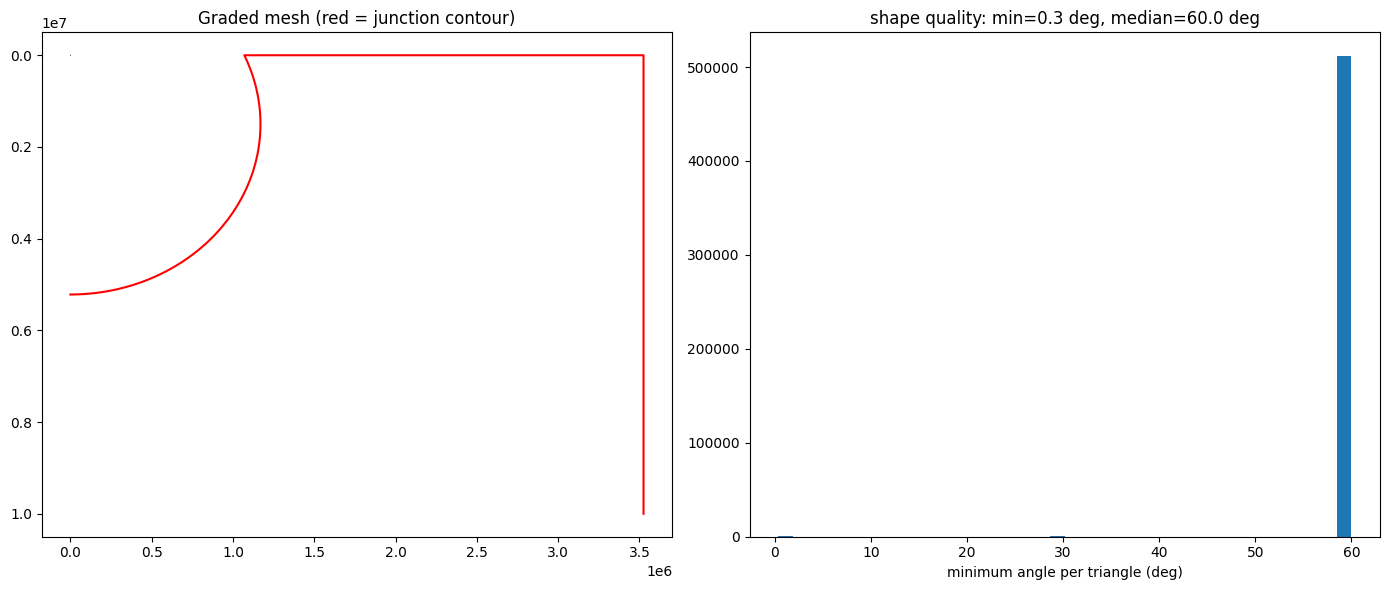

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].triplot(pts[:,1]*1e6, pts[:,0]*1e6, tris, linewidth=0.3, color="0.4")
axes[0].plot(junction_pts[:,1]*1e6, junction_pts[:,0]*1e6, "r-", linewidth=1.5)
axes[0].set_title("Graded mesh (red = junction contour)")
axes[0].invert_yaxis()

def min_angle_deg(pts, tris):
    p1,p2,p3 = pts[tris[:,0]], pts[tris[:,1]], pts[tris[:,2]]
    def ang(a,b,c):
        v1, v2 = b-a, c-a
        cosang = (v1*v2).sum(1)/(np.linalg.norm(v1,axis=1)*np.linalg.norm(v2,axis=1))
        return np.degrees(np.arccos(np.clip(cosang,-1,1)))
    A = ang(p1,p2,p3); B = ang(p2,p3,p1); C = ang(p3,p1,p2)
    return np.minimum(np.minimum(A,B),C)
    
min_ang = min_angle_deg(pts, tris)
axes[1].hist(min_ang, bins=40)
axes[1].set_xlabel("minimum angle per triangle (deg)")
axes[1].set_title(f"shape quality: min={min_ang.min():.1f} deg, median={np.median(min_ang):.1f} deg")
plt.tight_layout(); plt.show()

In [40]:
def junction_size_stats(pts, tris, junction_tree):
    coords = pts[tris]
    centroids = coords.mean(axis=1)
    x1, y1 = coords[:,0,0], coords[:,0,1]
    x2, y2 = coords[:,1,0], coords[:,1,1]
    x3, y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    e0 = np.linalg.norm(coords[:,1]-coords[:,0], axis=1)
    e1 = np.linalg.norm(coords[:,2]-coords[:,1], axis=1)
    e2 = np.linalg.norm(coords[:,0]-coords[:,2], axis=1)
    mean_edge = (e0 + e1 + e2) / 3.0
    d, _ = junction_tree.query(centroids)
    return d, mean_edge, np.sqrt(areas)

d, mean_edge, sqrt_area = junction_size_stats(pts, tris, junction_tree)

bin_edges_nm = np.array([0, 15, 30, 60, 100, 150, 250, 400, 600, 1000, 2000, np.inf])
bin_idx = np.digitize(d*1e9, bin_edges_nm)

header = (f"{'dist band (nm)':>16} {'n_tris':>8} {'mean edge (nm)':>15} "
        f"{'sqrt(area) (nm)':>16} {'target h(d) (nm)':>17}")
print(header)

for b in range(1, len(bin_edges_nm)):
    mask = bin_idx == b
    if not mask.any():
        continue
    lo = bin_edges_nm[b-1]
    hi = bin_edges_nm[b]
    label = f"{lo:.0f}-{hi:.0f}" if np.isfinite(hi) else f">{lo:.0f}"
    d_mid = d[mask].mean()
    target_h = h_min + (h_max - h_min)*(1 - np.exp(-d_mid/grade_length))
    row = (f"{label:>16} {mask.sum():>8} {mean_edge[mask].mean()*1e9:>15.1f} "
            f"{sqrt_area[mask].mean()*1e9:>16.1f} {target_h*1e9:>17.1f}")
    print(row)

near = d < 50e-9
far = d > 1e-6
near_edge = mean_edge[near].mean()
far_edge = mean_edge[far].mean()
print(f"\nnear-junction (<50nm) mean edge: {near_edge*1e9:.1f} nm (n={near.sum()})")
print(f"far-field (>1um) mean edge: {far_edge*1e9:.1f} nm (n={far.sum()})")
print(f"ratio far/near: {far_edge/near_edge:.2f}x "
    f"(target ratio h_max/h_min = {h_max/h_min:.2f}x)")


  dist band (nm)   n_tris  mean edge (nm)  sqrt(area) (nm)  target h(d) (nm)
           >2000   512971            15.1              9.9             300.0

near-junction (<50nm) mean edge: nan nm (n=0)
far-field (>1um) mean edge: 15.1 nm (n=512971)
ratio far/near: nanx (target ratio h_max/h_min = 20.00x)


/var/folders/zr/wpwk00wd2ygcddp_nzg3ytfm0000gn/T/ipykernel_3199/2937532679.py:39: RuntimeWarning: Mean of empty slice.
  near_edge = mean_edge[near].mean()


oversized triangles (edge > 3x local target h): 0 / 512971
sliver triangles (min angle < 2 deg):            438 / 512971
oversized AND sliver:     0
oversized but NOT sliver: 0
sliver but NOT oversized: 438


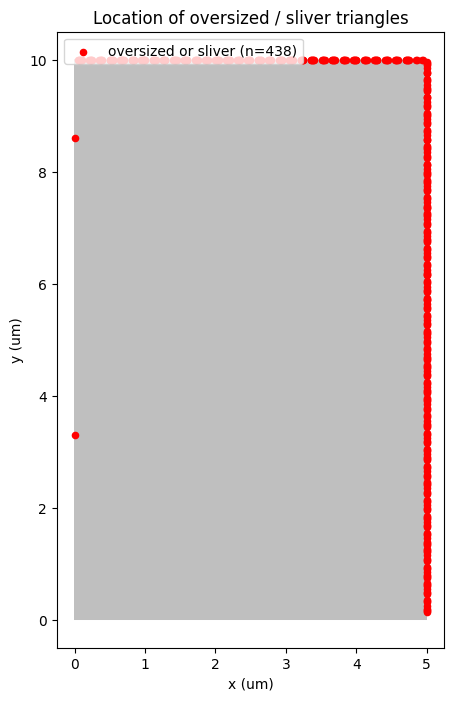


triangle 512959: min_angle=3.777 deg, mean_edge=200.2 nm, local target_h=300.0 nm
  vertices (um): [[4.358, 9.99], [4.5, 10.0], [4.2, 10.0]]

triangle 512965: min_angle=3.777 deg, mean_edge=200.2 nm, local target_h=300.0 nm
  vertices (um): [[3.157, 9.99], [3.3, 10.0], [3.0, 10.0]]

triangle 512963: min_angle=3.777 deg, mean_edge=200.2 nm, local target_h=300.0 nm
  vertices (um): [[2.542, 9.99], [2.7, 10.0], [2.4, 10.0]]

triangle 512955: min_angle=3.777 deg, mean_edge=200.2 nm, local target_h=300.0 nm
  vertices (um): [[2.1, 10.0], [2.257, 9.99], [2.4, 10.0]]

triangle 512969: min_angle=3.777 deg, mean_edge=200.2 nm, local target_h=300.0 nm
  vertices (um): [[1.342, 9.99], [1.5, 10.0], [1.2, 10.0]]


In [41]:
def min_angle_deg(pts, tris):
    p1, p2, p3 = pts[tris[:,0]], pts[tris[:,1]], pts[tris[:,2]]
    def ang(a, b, c):
        v1, v2 = b - a, c - a
        cosang = (v1*v2).sum(1) / (np.linalg.norm(v1,axis=1)*np.linalg.norm(v2,axis=1))
        return np.degrees(np.arccos(np.clip(cosang, -1, 1)))
    A = ang(p1, p2, p3)
    B = ang(p2, p3, p1)
    C = ang(p3, p1, p2)
    return np.minimum(np.minimum(A, B), C)

ma = min_angle_deg(pts, tris)
centroids = pts[tris].mean(axis=1)
target_h_local = size_function(centroids)

oversized = mean_edge > 3 * target_h_local
sliver = ma < 2.0

print(f"oversized triangles (edge > 3x local target h): {oversized.sum()} / {len(tris)}")
print(f"sliver triangles (min angle < 2 deg):            {sliver.sum()} / {len(tris)}")
print(f"oversized AND sliver:     {(oversized & sliver).sum()}")
print(f"oversized but NOT sliver: {(oversized & ~sliver).sum()}")
print(f"sliver but NOT oversized: {(sliver & ~oversized).sum()}")

bad = oversized | sliver
fig, ax = plt.subplots(figsize=(5,8))
ax.triplot(pts[:,0]*1e6, pts[:,1]*1e6, tris, lw=0.3, color="gray", alpha=0.5)
ax.scatter(centroids[bad,0]*1e6, centroids[bad,1]*1e6, s=20, c="red",
            label=f"oversized or sliver (n={bad.sum()})")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.legend()
ax.set_title("Location of oversized / sliver triangles")
plt.show()

worst = np.argsort(-mean_edge)[:5]
for i in worst:
    tri_pts = pts[tris[i]]
    print(f"\ntriangle {i}: min_angle={ma[i]:.3f} deg, mean_edge={mean_edge[i]*1e9:.1f} nm, "
        f"local target_h={target_h_local[i]*1e9:.1f} nm")
    print(f"  vertices (um): {np.round(tri_pts*1e6, 3).tolist()}")


In [42]:
local_edge_verts = [(1,2), (2,0), (0,1)]   # edge k opposite local vertex k

def build_edges(tris):
    N = tris.max() + 1
    p = np.stack([tris[:, lp] for lp, lq in local_edge_verts], axis=1)
    q = np.stack([tris[:, lq] for lp, lq in local_edge_verts], axis=1)
    lo, hi = np.minimum(p, q), np.maximum(p, q)
    edge_sign = np.where(p < q, 1.0, -1.0)
    edge_key = lo.astype(np.int64)*N + hi.astype(np.int64)
    _, edge_gidx = np.unique(edge_key, return_inverse=True)
    edge_gidx = edge_gidx.reshape(tris.shape)
    return edge_gidx, edge_sign, edge_gidx.max() + 1

def tri_areas(pts, tris):
    c = pts[tris]
    x1, y1 = c[:,0,0], c[:,0,1]
    x2, y2 = c[:,1,0], c[:,1,1]
    x3, y3 = c[:,2,0], c[:,2,1]
    return 0.5*((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

def rt0_eval(x, tri_idx, local_k, pts, tris, areas, edge_sign):
    Pk = pts[tris[tri_idx, local_k]]
    return edge_sign[tri_idx, local_k] * (x - Pk) / (2*areas[tri_idx])

areas = tri_areas(pts, tris)
print(f"areas: min={areas.min():.3e} max={areas.max():.3e} any negative={(areas<0).any()}")

edge_gidx, edge_sign, n_edges = build_edges(tris)
n_boundary_edges = int((np.bincount(edge_gidx.ravel()) == 1).sum())
n_interior_edges = n_edges - n_boundary_edges
print(f"n_tris={len(tris)}  n_edges={n_edges}  interior={n_interior_edges}  boundary={n_boundary_edges}")
print(f"Euler check 3*n_tris == 2*n_interior + n_boundary: "
    f"{3*len(tris)} == {2*n_interior_edges + n_boundary_edges}")

areas: min=2.758e-18 max=1.560e-15 any negative=False
n_tris=512971  n_edges=769866  interior=769047  boundary=819
Euler check 3*n_tris == 2*n_interior + n_boundary: 1538913 == 1538913


P1 affine reproduction: max error = 8.470e-22
P1 affine gradient (should be exactly (1,0) everywhere): min=[ 1.00000000e+00 -7.95807864e-13], max=[1.0000000e+00 5.1159077e-13]


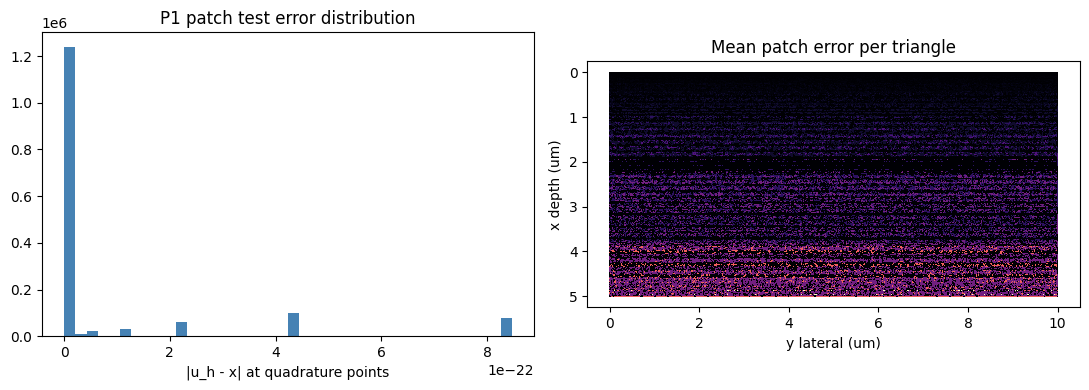

In [43]:
def get_batched_grads(pts, tris):
    coords = pts[tris]
    x1, y1 = coords[:,0,0], coords[:,0,1]
    x2, y2 = coords[:,1,0], coords[:,1,1]
    x3, y3 = coords[:,2,0], coords[:,2,1]
    a = 0.5*((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    b = np.stack([y2-y3, y3-y1, y1-y2], axis=1)
    c = np.stack([x3-x2, x1-x3, x2-x1], axis=1)
    grads = np.stack([b, c], axis=2) / (2*a)[:,None,None]
    return grads, a

def quad_rule_tri():
    a, b = 1/6, 2/3
    L = np.array([[b, a, a], [a, b, a], [a, a, b]])
    w = np.array([1/3, 1/3, 1/3])
    return L, w

def physical_quad_points(pts, tris, L):
    coords = pts[tris]
    return np.einsum('qk,tkd->tqd', L, coords)

def p1_eval_at_quad(u_nodal, tris, L_quad):
    u_tri = u_nodal[tris]
    return np.einsum('qk,tk->tq', L_quad, u_tri)

def p1_grad_eval(u_nodal, tris, grads):
    u_tri = u_nodal[tris]
    return np.einsum('tk,tkd->td', u_tri, grads)

L_quad, w_quad = quad_rule_tri()
grads, _ = get_batched_grads(pts, tris)
Xq = physical_quad_points(pts, tris, L_quad)

u_affine = pts[:, 0].copy()
u_at_quad = p1_eval_at_quad(u_affine, tris, L_quad)
patch_err = np.abs(u_at_quad - Xq[:,:,0])
print(f"P1 affine reproduction: max error = {patch_err.max():.3e}")

u_grad = p1_grad_eval(u_affine, tris, grads)
print(f"P1 affine gradient (should be exactly (1,0) everywhere): "
    f"min={u_grad.min(axis=0)}, max={u_grad.max(axis=0)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(patch_err.ravel(), bins=40, color='steelblue')
axes[0].set_xlabel('|u_h - x| at quadrature points')
axes[0].set_title('P1 patch test error distribution')
axes[1].tripcolor(pts[:,1]*1e6, pts[:,0]*1e6, tris, patch_err.mean(axis=1),
                   shading='flat', cmap='magma')
axes[1].invert_yaxis()
axes[1].set_aspect('equal')
axes[1].set_title('Mean patch error per triangle')
axes[1].set_xlabel('y lateral (um)')
axes[1].set_ylabel('x depth (um)')
plt.tight_layout()
plt.show()


In [44]:
def rt0_eval_batch(Xq, pts, tris, areas, edge_sign):
    Pk = pts[tris]
    diff = Xq[:, :, None, :] - Pk[:, None, :, :]
    W = diff / (2*areas)[:, None, None, None]
    return W * edge_sign[:, None, :, None]

def rt0_div(areas, edge_sign):
    return edge_sign / areas[:, None]

# refresh quadrature / grads from current mesh (helpers defined in previous cell)
L_quad, w_quad = quad_rule_tri()
Xq = physical_quad_points(pts, tris, L_quad)
grads, _ = get_batched_grads(pts, tris)

W_quad = rt0_eval_batch(Xq, pts, tris, areas, edge_sign)
div_W = rt0_div(areas, edge_sign)

for k in range(3):
    single = rt0_eval(Xq[0, 0], 0, k, pts, tris, areas, edge_sign)
    batched = W_quad[0, 0, k]
    assert np.allclose(single, batched), f"mismatch at local dof {k}"
print("batched RT0 evaluator matches single-point rt0_eval -- OK")
print(f"Xq shape={Xq.shape}, W_quad shape={W_quad.shape}, div_W shape={div_W.shape}")


batched RT0 evaluator matches single-point rt0_eval -- OK
Xq shape=(512971, 3, 2), W_quad shape=(512971, 3, 3, 2), div_W shape=(512971, 3)


In [45]:
# conformity spot-check on a real shared interior edge
flat = edge_gidx.ravel()
tri_idx_flat = np.repeat(np.arange(len(tris)), 3)
local_idx_flat = np.tile(np.arange(3), len(tris))
order = np.argsort(flat)
flat_s, tri_s, local_s = flat[order], tri_idx_flat[order], local_idx_flat[order]
interior_gid = np.where(np.bincount(flat) == 2)[0][0]
pos = np.where(flat_s == interior_gid)[0]
tri_a, local_a = tri_s[pos[0]], local_s[pos[0]]
tri_b, local_b = tri_s[pos[1]], local_s[pos[1]]

a0, a1 = local_edge_verts[local_a]
Pa, Pb_ = pts[tris[tri_a, a0]], pts[tris[tri_a, a1]]
mid = 0.5*(Pa + Pb_)
edge_vec = Pb_ - Pa
normal = np.array([edge_vec[1], -edge_vec[0]])
normal = normal / np.linalg.norm(normal)

wA = rt0_eval(mid, tri_a, local_a, pts, tris, areas, edge_sign)
wB = rt0_eval(mid, tri_b, local_b, pts, tris, areas, edge_sign)
print(f"shared edge: tri {tri_a}(local {local_a}) <-> tri {tri_b}(local {local_b})")
print(f"normal flux match (this is the real H(div) requirement): {np.isclose(wA@normal, wB@normal)}")
print(f"full vector match (not expected for RT0 in general): {np.allclose(wA, wB)}")


shared edge: tri 8262(local 1) <-> tri 8261(local 0)
normal flux match (this is the real H(div) requirement): True
full vector match (not expected for RT0 in general): False


In [46]:
def p1_stiffness_local(grads, areas):
    return np.einsum('tid,tjd->tij', grads, grads) * areas[:, None, None]

def p1_mass_local(L_quad, w_quad, areas, weight_at_quad=None):
    n_tris = areas.shape[0]
    if weight_at_quad is None:
        weight_at_quad = np.ones((n_tris, len(w_quad)))
    Lw = L_quad * w_quad[:, None]
    return np.einsum('qi,qj,tq->tij', Lw, L_quad, weight_at_quad) * areas[:, None, None]

def rt0_mass_local(W_quad, w_quad, areas, weight_at_quad=None):
    n_tris, n_quad = W_quad.shape[0], W_quad.shape[1]
    if weight_at_quad is None:
        weight_at_quad = np.ones((n_tris, n_quad))
    dot = np.einsum('tqid,tqjd->tqij', W_quad, W_quad)
    return np.einsum('tqij,q,tq->tij', dot, w_quad, weight_at_quad) * areas[:, None, None]

def rt0_p0_coupling_local(edge_sign):
    return edge_sign.copy()   # div(w_k)*Area = edge_sign[k] exactly -- no quadrature needed

# consistency check: same answer via the already-verified rt0_div path
B_check = rt0_div(areas, edge_sign) * areas[:, None]
print(f"B_local matches edge_sign exactly: {np.allclose(B_check, edge_sign)}")


B_local matches edge_sign exactly: True


In [47]:
def p0_eval_at_quad(phi_per_tri, n_quad):
    return np.repeat(phi_per_tri[:, None], n_quad, axis=1)   # (n_tris, n_quad)


In [48]:
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh

def assemble_p1_matrix(local_mats, tris, n_pts):
    n_tris = tris.shape[0]
    rows = np.broadcast_to(tris[:, :, None], (n_tris, 3, 3)).ravel()
    cols = np.broadcast_to(tris[:, None, :], (n_tris, 3, 3)).ravel()
    return coo_matrix((local_mats.ravel(), (rows, cols)), shape=(n_pts, n_pts)).tocsr()

def assemble_rt0_matrix(local_mats, edge_gidx, n_edges):
    n_tris = edge_gidx.shape[0]
    rows = np.broadcast_to(edge_gidx[:, :, None], (n_tris, 3, 3)).ravel()
    cols = np.broadcast_to(edge_gidx[:, None, :], (n_tris, 3, 3)).ravel()
    return coo_matrix((local_mats.ravel(), (rows, cols)), shape=(n_edges, n_edges)).tocsr()

def assemble_b_matrix(b_local, edge_gidx, n_tris, n_edges):
    rows = np.repeat(np.arange(n_tris), 3)
    cols = edge_gidx.ravel()
    return coo_matrix((b_local.ravel(), (rows, cols)), shape=(n_tris, n_edges)).tocsr()

# ── full device mesh (production assembly — no eigsh / spy here) ─────────────
n_pts = pts.shape[0]

K_local = p1_stiffness_local(grads, areas)
K_P1 = assemble_p1_matrix(K_local, tris, n_pts)

M_RT0_local = rt0_mass_local(W_quad, w_quad, areas)
M_RT0 = assemble_rt0_matrix(M_RT0_local, edge_gidx, n_edges)

B_local = rt0_p0_coupling_local(edge_sign)
B_global = assemble_b_matrix(B_local, edge_gidx, len(tris), n_edges)

diffK = K_P1 - K_P1.T
diffM = M_RT0 - M_RT0.T
print(f"K_P1:     shape={K_P1.shape}, nnz={K_P1.nnz}, "
      f"symmetry err={np.abs(diffK).max() if diffK.nnz else 0.0:.3e}")
print(f"M_RT0:    shape={M_RT0.shape}, nnz={M_RT0.nnz}, "
      f"symmetry err={np.abs(diffM).max() if diffM.nnz else 0.0:.3e}")
print(f"B_global: shape={B_global.shape}, nnz={B_global.nnz}")

ones = np.ones(n_pts)
k1 = np.linalg.norm(K_P1 @ ones) / np.linalg.norm(ones)
print(f"K_P1 @ 1: relative residual {k1:.3e}  (~0 for Neumann Laplacian)")

# ── cheap sanity check on tiny structured mesh (eigsh + spy only here) ───────
def build_toy_mesh(n=5):
    x = np.linspace(0, Lx, n)
    y = np.linspace(0, Ly, n)
    xx, yy = np.meshgrid(x, y, indexing='ij')
    toy_pts = np.column_stack([xx.ravel(), yy.ravel()])
    toy_tris = []
    for i in range(n - 1):
        for j in range(n - 1):
            bl = i*n + j
            br = i*n + (j + 1)
            tl = (i + 1)*n + j
            tr = (i + 1)*n + (j + 1)
            toy_tris.append([bl, br, tl])
            toy_tris.append([br, tr, tl])
    return toy_pts, np.array(toy_tris)

toy_pts, toy_tris = build_toy_mesh(n=5)
toy_grads, toy_areas = get_batched_grads(toy_pts, toy_tris)
toy_L, toy_w = quad_rule_tri()
toy_Xq = physical_quad_points(toy_pts, toy_tris, toy_L)
toy_edge_gidx, toy_edge_sign, toy_n_edges = build_edges(toy_tris)
toy_W = rt0_eval_batch(toy_Xq, toy_pts, toy_tris, toy_areas, toy_edge_sign)

toy_K = assemble_p1_matrix(p1_stiffness_local(toy_grads, toy_areas), toy_tris, len(toy_pts))
toy_M = assemble_rt0_matrix(rt0_mass_local(toy_W, toy_w, toy_areas), toy_edge_gidx, toy_n_edges)
toy_B = assemble_b_matrix(rt0_p0_coupling_local(toy_edge_sign), toy_edge_gidx, len(toy_tris), toy_n_edges)

lam_min_K = eigsh(toy_K, k=1, which='SA', return_eigenvectors=False)[0]
lam_min_M = eigsh(toy_M, k=1, which='SA', return_eigenvectors=False)[0]
print(f"\n[toy mesh n={len(toy_pts)} nodes]  K min eig={lam_min_K:.3e} (~0),  M min eig={lam_min_M:.3e} (>0)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, M, title in zip(axes, [toy_K, toy_M, toy_B],
                        ['toy K_P1', 'toy M_RT0', 'toy B']):
    ax.spy(M, markersize=2)
    ax.set_title(f"{title}  {M.shape}")
    ax.set_aspect('equal')
plt.suptitle('Matrix sparsity sanity check (toy 5x5 mesh only)', y=1.02)
plt.tight_layout()
plt.show()


K_P1:     shape=(256896, 256896), nnz=1796628, symmetry err=0.000e+00
M_RT0:    shape=(769866, 769866), nnz=3847692, symmetry err=0.000e+00
B_global: shape=(512971, 769866), nnz=1538913


KeyboardInterrupt: 

In [ ]:
# ── Physical constants + normalization (slotboom_math.md §3) ─────────────────
q     = 1.602e-19
eps0  = 8.854e-12
k_B   = 1.381e-23
T     = 300.0
eps_r = 11.7
eps   = eps_r * eps0
ni    = 1.5e16          # m^-3

Vt = k_B * T / q        # thermal voltage (V)

# Contact windows on surface x = 0
y_E_lo, y_E_hi = 0.0e-6, 3.0e-6      # Gamma_E emitter
y_B_lo, y_B_hi = 8.0e-6, 10.0e-6     # Gamma_B base
# oxide gap (Neumann) on x=0: y in (y_E_hi, y_B_lo)

# Applied biases (V)
V_E, V_B, V_C = 0.0, 0.65, 0.5

# Normalization scales
C_s = ni
mu_n, mu_p = 0.145, 0.0466          # m^2/(V*s)
D_n = mu_n * Vt
D_s = D_n
L_s = np.sqrt(eps * Vt / (q * C_s))
tau_s = L_s**2 / D_s

gamma_n = 1.0                         # by choice D_s = D_n
gamma_p = mu_n / mu_p                 # ~ 3.111

tau_n0 = tau_p0 = 0.5e-7              # s
tau_n_hat = tau_n0 / tau_s            # ~ 0.1624 (shared D_s ref)
tau_p_hat = tau_p0 / tau_s

print(f"V_t = {Vt*1e3:.4f} mV")
print(f"L_s = {L_s*1e6:.4f} um,  D_s = {D_s:.4e} m^2/s")
print(f"gamma_p = {gamma_p:.4f},  tau_hat = {tau_n_hat:.4f}")

V_t = 25.8614 mV
L_s = 33.3897 um,  D_s = 3.7499e-03 m^2/s
gamma_p = 3.1116,  tau_hat = 0.1682


In [ ]:
def normalized_doping(x, y):
    """N_hat = N / n_i (uses doping_profile from mesh cell)."""
    return doping_profile(x, y) / ni

def contact_phi(V_applied):
    """Normalized quasi-Fermi potential at ohmic contact: phi_k = V_k / V_t."""
    return V_applied / Vt

def dirichlet_psi(x, y, segment):
    """
    Prescribed normalized electrostatic potential on Gamma_E, Gamma_B, Gamma_C.
    psi_k = phi_k + asinh(N_hat/2); varies pointwise with local doping.
    """
    N_hat = normalized_doping(x, y)
    if segment == 'emitter':
        return contact_phi(V_E) + np.arcsinh(N_hat / 2.0)
    if segment == 'base':
        return contact_phi(V_B) + np.arcsinh(N_hat / 2.0)
    if segment == 'collector':
        return contact_phi(V_C) + np.arcsinh(N_hat / 2.0)
    raise ValueError(f"unknown Dirichlet segment: {segment}")

def dirichlet_phi_p(x, y, segment):
    """Prescribed Phi_p = exp(phi_p) on ohmic contacts (phi_p = V_k/V_t)."""
    if segment == 'emitter':
        return np.exp(contact_phi(V_E))
    if segment == 'base':
        return np.exp(contact_phi(V_B))
    if segment == 'collector':
        return np.exp(contact_phi(V_C))
    raise ValueError(f"unknown Dirichlet segment: {segment}")

def dirichlet_phi_n(x, y, segment):
    """Prescribed Phi_n = exp(-phi_n) on ohmic contacts."""
    if segment == 'emitter':
        return np.exp(-contact_phi(V_E))
    if segment == 'base':
        return np.exp(-contact_phi(V_B))
    if segment == 'collector':
        return np.exp(-contact_phi(V_C))
    raise ValueError(f"unknown Dirichlet segment: {segment}")

def dirichlet_newton_delta(x, y, segment):
    """Poisson Newton correction: delta = 0 on all Dirichlet contacts."""
    return 0.0

def neumann_normal_derivative(x, y, segment):
    """
    Homogeneous Neumann on Gamma_N: d(psi)/d(nu) = d(Phi_p)/d(nu) = d(Phi_n)/d(nu) = 0.
    Natural BC in weak form -- no boundary integral term.
    """
    return 0.0

In [ ]:
def classify_boundary_point(x, y, tol=1e-12):
    """
    Tag a point on d(Omega) as 'emitter', 'base', 'collector', or 'neumann'.
    Returns None if not on the boundary (within tol).
    Coordinates: x = depth in [0, Lx], y = lateral in [0, Ly].
    """
    x = float(np.asarray(x).reshape(()))
    y = float(np.asarray(y).reshape(()))

    on_x0  = x < tol
    on_xLx = x > Lx - tol
    on_y0  = y < tol
    on_yLy = y > Ly - tol

    if on_x0:
        if y <= y_E_hi + tol:
            return 'emitter'
        if y >= y_B_lo - tol:
            return 'base'
        if y > y_E_hi + tol and y < y_B_lo - tol:
            return 'neumann'          # oxide gap on surface
    if on_xLx:
        return 'collector'
    if on_y0 or on_yLy:
        return 'neumann'              # lateral side edges
    return None

In [ ]:
BC_COLORS = {
    'emitter':   '#1f5fd1',
    'base':      '#d11f1f',
    'collector': '#1fa05a',
    'neumann':   '#b21fd1',
}

def identify_boundary_nodes(points, tol=1e-12):
    x, y = points[:, 0], points[:, 1]
    on_boundary = (x < tol) | (x > Lx - tol) | (y < tol) | (y > Ly - tol)
    bnd_idx = np.where(on_boundary)[0]

    seg_lists = {k: [] for k in ['emitter', 'base', 'collector', 'neumann']}
    for i in bnd_idx:
        seg = classify_boundary_point(x[i], y[i], tol=tol)
        if seg is not None:
            seg_lists[seg].append(i)

    boundary_nodes = {k: np.array(v, dtype=int) for k, v in seg_lists.items()}
    boundary_nodes['dirichlet'] = np.unique(np.concatenate([
        boundary_nodes['emitter'],
        boundary_nodes['base'],
        boundary_nodes['collector'],
    ]))
    return boundary_nodes

boundary_nodes = identify_boundary_nodes(pts)
for name in ['emitter', 'base', 'collector', 'neumann', 'dirichlet']:
    nodes = boundary_nodes[name]
    print(f"{name:10s}: {len(nodes):4d} nodes,  first few: {nodes[:5]}")

fig, ax = plt.subplots(figsize=(6, 8))
ax.triplot(pts[:,1]*1e6, pts[:,0]*1e6, tris, color="0.85", lw=0.25)
for seg in ['emitter', 'base', 'collector', 'neumann']:
    nodes = boundary_nodes[seg]
    if len(nodes):
        ax.scatter(pts[nodes,1]*1e6, pts[nodes,0]*1e6, s=14, c=BC_COLORS[seg],
                   label=f"Gamma_{seg[0].upper()} ({len(nodes)} nodes)", zorder=3)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlabel('y lateral (um)')
ax.set_ylabel('x depth (um)')
ax.set_title('Boundary nodes by contact / Neumann segment')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

emitter   :   13 nodes,  first few: [0 1 2 3 4]
base      :    9 nodes,  first few: [34 35 36 37 38]
collector :   35 nodes,  first few: [91 92 93 94 95]
neumann   :   74 nodes,  first few: [12 13 14 15 16]
dirichlet :   57 nodes,  first few: [0 1 2 3 4]


In [ ]:
def edge_outward_normal(p0, p1, tol=1e-12):
    mid = 0.5 * (p0 + p1)
    tangent = p1 - p0
    tang_len = np.linalg.norm(tangent)
    if tang_len < tol:
        raise ValueError("degenerate boundary edge")
    tangent /= tang_len
    n_candidates = np.array([[-tangent[1], tangent[0]],
                              [ tangent[1], -tangent[0]]])
    x, y = mid
    if x < tol:
        outward = np.array([-1.0, 0.0])
    elif x > Lx - tol:
        outward = np.array([ 1.0, 0.0])
    elif y < tol:
        outward = np.array([ 0.0, -1.0])
    elif y > Ly - tol:
        outward = np.array([ 0.0,  1.0])
    else:
        outward = np.array([0.0, 0.0])
    n = n_candidates[np.argmax(n_candidates @ outward)]
    return n / np.linalg.norm(n)

def identify_boundary_edges(pts, tris, edge_gidx, tol=1e-12):
    counts = np.bincount(edge_gidx.ravel())
    boundary_gids = np.where(counts == 1)[0]
    flat = edge_gidx.ravel()
    tri_flat = np.repeat(np.arange(len(tris)), 3)
    local_flat = np.tile(np.arange(3), len(tris))

    gid_list, seg_list, len_list, nrm_list, mid_list = [], [], [], [], []
    for gid in boundary_gids:
        pos = np.where(flat == gid)[0][0]
        t, lk = tri_flat[pos], local_flat[pos]
        v0, v1 = local_edge_verts[lk]
        p0, p1 = pts[tris[t, v0]], pts[tris[t, v1]]
        mid = 0.5 * (p0 + p1)
        seg = classify_boundary_point(mid[0], mid[1], tol=tol)
        if seg is None:
            continue
        gid_list.append(gid)
        seg_list.append(seg)
        len_list.append(np.linalg.norm(p1 - p0))
        nrm_list.append(edge_outward_normal(p0, p1, tol=tol))
        mid_list.append(mid)

    return {
        'gids':      np.array(gid_list, dtype=int),
        'segments':  np.array(seg_list),
        'lengths':   np.array(len_list),
        'normals':   np.vstack(nrm_list),
        'midpoints': np.vstack(mid_list),
    }

bnd_edges = identify_boundary_edges(pts, tris, edge_gidx)
for seg in ['emitter', 'base', 'collector', 'neumann']:
    m = bnd_edges['segments'] == seg
    print(f"{seg:10s}: {m.sum():4d} boundary edges")

fig, ax = plt.subplots(figsize=(6, 8))
ax.triplot(pts[:,1]*1e6, pts[:,0]*1e6, tris, color="0.9", lw=0.2)
for seg in ['emitter', 'base', 'collector', 'neumann']:
    m = bnd_edges['segments'] == seg
    mids = bnd_edges['midpoints'][m]
    if len(mids):
        ax.scatter(mids[:,1]*1e6, mids[:,0]*1e6, s=10, c=BC_COLORS[seg],
                   label=f"{seg} edges ({m.sum()})", zorder=3)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlabel('y lateral (um)')
ax.set_ylabel('x depth (um)')
ax.set_title('Boundary edges (RT0 DOFs live on edges)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

emitter   :   12 boundary edges
base      :    8 boundary edges
collector :   34 boundary edges
neumann   :   77 boundary edges


In [ ]:
def srh_recombination_hat(psi, phi_p, phi_n):
    """
    Normalized SRH rate R_hat (volume source for continuity equations).
    R_hat = (n_hat p_hat - 1) / (tau_n_hat (p_hat+1) + tau_p_hat (n_hat+1))
    with n_hat = Phi_n exp(psi),  p_hat = Phi_p exp(-psi).
    """
    n_hat = phi_n * np.exp(psi)
    p_hat = phi_p * np.exp(-psi)
    num = n_hat * p_hat - 1.0
    den = tau_n_hat * (p_hat + 1.0) + tau_p_hat * (n_hat + 1.0)
    return num / den

In [ ]:
# Prescribed Dirichlet psi on all mesh nodes (for visualization before solve)
psi_bc_nodes = np.zeros(len(pts))
seg_for_node = np.full(len(pts), '', dtype=object)
for seg in ['emitter', 'base', 'collector']:
    for i in boundary_nodes[seg]:
        psi_bc_nodes[i] = dirichlet_psi(pts[i,0], pts[i,1], seg)
        seg_for_node[i] = seg

test_pts = {
    'emitter':   (0.0, 1.5e-6),
    'base':      (0.0, 9.0e-6),
    'collector': (Lx,  5.0e-6),
}
print(f"{'seg':10s}  {'psi':>10s}  {'Phi_p':>12s}  {'Phi_n':>12s}")
for seg, (x0, y0) in test_pts.items():
    print(f"{seg:10s}  {dirichlet_psi(x0,y0,seg):10.4f}  "
          f"{dirichlet_phi_p(x0,y0,seg):12.4e}  {dirichlet_phi_n(x0,y0,seg):12.4e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
tpc = axes[0].tripcolor(pts[:,1]*1e6, pts[:,0]*1e6, tris, psi_bc_nodes,
                        shading='gouraud', cmap='viridis')
axes[0].invert_yaxis()
axes[0].set_aspect('equal')
axes[0].set_title('Prescribed contact psi on Dirichlet nodes')
axes[0].set_xlabel('y lateral (um)')
axes[0].set_ylabel('x depth (um)')
plt.colorbar(tpc, ax=axes[0], label='psi (normalized)')

vals, labs = [], []
for seg in ['emitter', 'base', 'collector']:
    nodes = boundary_nodes[seg]
    vals.append(psi_bc_nodes[nodes])
    labs.append(seg)
axes[1].boxplot(vals, labels=labs)
axes[1].set_ylabel('psi on contact nodes')
axes[1].set_title('Dirichlet spread from local doping N_hat')
plt.tight_layout()
plt.show()

seg                psi         Phi_p         Phi_n
emitter        24.2288    1.0000e+00    1.0000e+00
base            7.8139    8.2327e+10    1.2147e-11
collector      30.4394    2.4921e+08    4.0126e-09


In [ ]:
def p1_load_local(L_quad, w_quad, areas, f_at_quad):
    """Element load vector F^e_i = integral f phi_i dA.  f_at_quad: (n_tris, n_quad)."""
    Lw = L_quad * w_quad[:, None]
    return areas[:, None] * (f_at_quad @ Lw)

def assemble_p1_load_vector(tris, load_local, n_pts):
    F = np.zeros(n_pts)
    for k in range(3):
        np.add.at(F, tris[:, k], load_local[:, k])
    return F

def assemble_p1_rhs(pts, tris, L_quad, w_quad, areas, source_fn):
    Xq = physical_quad_points(pts, tris, L_quad)
    f_q = np.asarray(source_fn(Xq[:, :, 0], Xq[:, :, 1]))
    load_local = p1_load_local(L_quad, w_quad, areas, f_q)
    return assemble_p1_load_vector(tris, load_local, len(pts))

def volume_source_zero(x, y):
    return np.zeros_like(np.asarray(x))

def volume_source_test(x, y):
    """Constant source for pipeline check only (not physical Poisson RHS)."""
    return np.ones_like(np.asarray(x))

F_zero = assemble_p1_rhs(pts, tris, L_quad, w_quad, areas, volume_source_zero)
F_test = assemble_p1_rhs(pts, tris, L_quad, w_quad, areas, volume_source_test)
print(f"F (zero source):  ||F||={np.linalg.norm(F_zero):.3e},  sum={F_zero.sum():.3e}")
print(f"F (test f=1):     ||F||={np.linalg.norm(F_test):.3e},  sum={F_test.sum():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, F, title in zip(axes, [F_zero, F_test],
                        ['RHS with f=0 (physical Laplacian solve)',
                         'RHS with f=1 (assembly sanity check)']):
    ax.triplot(pts[:,1]*1e6, pts[:,0]*1e6, tris, color='0.85', lw=0.2)
    tpc = ax.tripcolor(pts[:,1]*1e6, pts[:,0]*1e6, tris, F,
                       shading='gouraud', cmap='magma')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('y lateral (um)')
    ax.set_ylabel('x depth (um)')
    plt.colorbar(tpc, ax=ax, label='F_i')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.sparse.linalg import spsolve

def apply_dirichlet_p1_and_solve(K, F, pts, boundary_nodes, value_fn,
                                  dirichlet_segs=('emitter', 'base', 'collector')):
    """
    Row-elimination Dirichlet BC on P1 nodes, then solve K u = F.
    Neumann edges: homogeneous -- no contribution (natural BC).
    """
    K = K.tolil(copy=True)
    F = F.copy()
    for seg in dirichlet_segs:
        for node in boundary_nodes[seg]:
            g = value_fn(pts[node, 0], pts[node, 1], seg)
            K.rows[node] = [node]
            K.data[node] = [1.0]
            F[node] = g
    return spsolve(K.tocsr(), F)

# Prototype linear solve:  -laplacian(psi) = 0  with contact Dirichlet psi^bc
# (harmonic extension -- verifies mesh + K + BC pipeline before nonlinear Poisson)
F = assemble_p1_rhs(pts, tris, L_quad, w_quad, areas, volume_source_zero)
psi_harmonic = apply_dirichlet_p1_and_solve(K_P1, F, pts, boundary_nodes, dirichlet_psi)

# Dirichlet check
bc_err = []
for seg in ['emitter', 'base', 'collector']:
    nodes = boundary_nodes[seg]
    g = np.array([dirichlet_psi(pts[i,0], pts[i,1], seg) for i in nodes])
    bc_err.append(np.max(np.abs(psi_harmonic[nodes] - g)))
print(f"max |psi - psi_bc| on contacts: emitter={bc_err[0]:.2e}, base={bc_err[1]:.2e}, collector={bc_err[2]:.2e}")
print(f"psi range: [{psi_harmonic.min():.3f}, {psi_harmonic.max():.3f}]")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

tpc = axes[0].tripcolor(pts[:,1]*1e6, pts[:,0]*1e6, tris, psi_harmonic,
                        shading='gouraud', cmap='coolwarm')
axes[0].triplot(pts[:,1]*1e6, pts[:,0]*1e6, tris, color='k', lw=0.08, alpha=0.35)
axes[0].invert_yaxis()
axes[0].set_aspect('equal')
axes[0].set_title('FEM solution: harmonic psi (Laplacian, contact BCs)')
axes[0].set_xlabel('y lateral (um)')
axes[0].set_ylabel('x depth (um)')
plt.colorbar(tpc, ax=axes[0], label='psi')

# prescribed BC field (NaN in interior)
psi_prescribed = np.full(len(pts), np.nan)
for seg in ['emitter', 'base', 'collector']:
    nodes = boundary_nodes[seg]
    for i in nodes:
        psi_prescribed[i] = dirichlet_psi(pts[i,0], pts[i,1], seg)
axes[1].tripcolor(pts[:,1]*1e6, pts[:,0]*1e6, tris, psi_prescribed,
                   shading='gouraud', cmap='coolwarm')
axes[1].invert_yaxis()
axes[1].set_aspect('equal')
axes[1].set_title('Prescribed contact psi (Dirichlet data)')
axes[1].set_xlabel('y lateral (um)')
axes[1].set_ylabel('x depth (um)')

# 1D cross-sections at fixed lateral y
y_slices = [1.5e-6, 5.0e-6, 9.0e-6]
colors = ['#1f5fd1', '0.4', '#d11f1f']
ax = axes[2]
for y0, c, lab in zip(y_slices, colors, ['y=1.5um (emitter)', 'y=5um', 'y=9um (base)']):
    tol = 0.05e-6
    mask = np.abs(pts[:,1] - y0) < tol
    order = np.argsort(pts[mask, 0])
    ax.plot(pts[mask,0][order]*1e6, psi_harmonic[mask][order], '-o', ms=3, color=c, label=lab)
ax.set_xlabel('x depth (um)')
ax.set_ylabel('psi')
ax.set_title('Cross-sections of harmonic psi')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()